# NNDL Project - Music Genre Classification
Group members: Thimona Chrusciel and Nicolas Vogel

Submission date: 27th Mai 2025

Course: Neural networks and deep learning



## Sections
0. Introduction
1. Pre-Settings, Imports and Data Loading
2. Data Analysis and Visualization
3. Data Preprocessing
4. Model Building and Training
5. Evaluation
6. Final Remarks

## 0. Introduction
### 0.1 Task
In our project we want to create a CNN to classify genres of music audio which is converted into mel-spectrograms. In a first step the model should be trained on the GTZAN dataset as in a second step the model is finetuned on our own data. To compare the performance of our model, already existing models such as VGG16, VGG19, ResNet18 and MobileNet_v2 are used in a transfer learning approach also finetuned on our own data. 

**Training Methods**
It was planned to execute the training on the earth cluster. Due to many issues in the end the training was only performed on a local machine. Namely, a MacBook Air (2020) M1. For further information see section 6.2 Problems Encountered. 

### 0.2 Related Work
In recent years, Convolutional Neural Networks (CNNs) have become a popular approach for music genre classification, particularly when using time-frequency representations such as mel-spectrograms. Leitner et al. (2019) demonstrate the effectiveness of CNNs on mel-spectrograms for general audio recognition tasks. Vines et al. (2022) compare various spectral features and show that mel-spectrograms provide a strong basis for CNN-based classification. Pons et al. (2016) propose musically motivated CNN architectures, emphasizing the importance of domain-specific filter shapes to capture temporal and spectral patterns in music. Lee et al. (2017) introduce SampleCNN, a model that operates directly on raw audio using small convolutional filters, achieving competitive results without handcrafted features. More recently, Spijkervet et al. (2019) explore contrastive learning to learn generalizable musical representations, which can be fine-tuned for downstream tasks such as genre classification. These works underline the variety of approaches in audio-based genre classification and inform our own model design and evaluation strategy.
Lastly the publication by Sturm et al. (2014) should to be mentioned. It gives a broad overview over music genre recognition (MGR) and also goes in to detail about the GTZAN dataset. 


Data and analysis: 
The GTZAN dataset consists of 10 genres (classes) each with 100 samples of 30 seconds length. The audio samples are in .wav format and were converted into mel-spectrograms (wav-to-mel.py). Our own data contains 4 genres (all electronic music) each have 92 samples per class and are converted from .mp3 to .wav to mel-spectrograms. The Data is further presented in the section "2. Data Analysis and Visualization".



Sources: 
- 2014, Sturm et al. The State of the Art Ten Years After a State of the Art: Future Research in Music Information Retrieval (https://doi.org/10.1080/09298215.2014.894533)
- 2016, Pons et al., Experimenting with Musically Motivated Convolutional Neural Networks (https://doi.org/10.1109/CBMI.2016.7500246)
- 2017, Lee et al., SampleCNN: End-to-End Deep Convolutional Neural Networks Using Very Small Filters for Music Classification (https://doi.org/10.3390/app8010150) 
- 2019, Leitner et al., Audio Recognition using Mel Spectrograms and Convolution Neural Networks 
- 2019, Spijkervet et al. Contrastive Learning of Musical Representations (https://doi.org/10.48550/arXiv.2103.09410)
- 2022, Vines et al. Comparison of Audio Spectral Features in a Convolutional Neural Network

### 0.3 Submission Data
Here the submission data is listed and briefly explained: 



| **File / Folder**                     | **Description**                                                                 |
|--------------------------------------|---------------------------------------------------------------------------------|
| `environment_minimal.yml`           | Environment file for the project, reduced to minimal requirements               |
| `genres_new_pers/`                  | Folder with our `.wav` files of our own data, 4 folders – one per genre         |
| `genres_original/`                  | Folder with `.wav` files of the GTZAN dataset, 10 folders – one per genre (Kaggle) |
| `HyperparaTuning_logs.csv`          | Log file with results of hyperparameter tuning for plotting                     |
| `images_new_pers/`                  | Folder with mel-spectrograms of our data, 4 folders – one per genre             |
| `images_original/`                  | Folder with mel-spectrograms of GTZAN data, 10 folders – one per genre (Kaggle) |
| `images_original_small/`            | Folder with small images of GTZAN, 10 folders – one per genre (Kaggle)          |
| `main.ipynb`                        | Jupyter Notebook with the code of the project (this file)                       |
| `Model_dev_comparison.csv`          | Log file with results of model development comparison for plotting              |
| `Model_final_comparison.csv`        | Log file with results of final model comparison for plotting                    |
| `Model_finetune.csv`                | Log file with results of the finetune model comparison for plotting             |
| `mp3_to_mel.py`                     | Script to convert `.mp3` files to mel-spectrograms (includes `.wav` export)     |
| `wav_to_mel.py`                     | Script to convert `.wav` files to mel-spectrograms                              |
| `Plots_Base_Model/`                 | Folder with plots of the final trained base model (SimpleCNN)                   |
| `Plots_Dev_Model/`                  | Folder with plots of model development                                          |
| `Plots_Finetune_Model/`             | Folder with plots of the finetuned model                                        |
| `SimpleCNN_ext_pretrained.pth`      | Pretrained model of the extended SimpleCNN                                      |


## 1. Pre-Settings, Imports and Data Loading
In this section we will set the pre-settings for the project, import all necessary libraries and load the data. The data is already converted into mel-spectrograms and stored in a folder structure.
### 1.1 Modules

In [1]:
# ======================= Module Imports ============================= #

# ========== Base Modules
import pandas as pd
import time
from datetime import date
import random
import numpy as np
import os

# ========== Image and audio Data visualization and analysis
from PIL import Image
import librosa
import matplotlib.image as mpimg
from IPython.display import Audio, display


# ========== Data handling
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
import collections
from torchvision import transforms
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from torch.utils.data import Subset, DataLoader

# ========= DL Modules
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
from tqdm import tqdm

# ======== Plotting and Model Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from IPython.display import HTML


### 1.2 Funcitonality Pre-settings
In this subsection pre settings can be set to control the functionality of the code. For example the model architecture to be trained can be chosen. To execute the exported python file on the cluster show_plot_files has to be disabled. For test runs file saving of summaries and plots can also be disabled. The current workig directory is and also the basic hyperparameter can be set here.

In [14]:
# ================ File Exports and Pre Settings ===================== #

# use small subset with number of samples per class:
use_subset = True
max_per_class = 20 # maximum number of spectrograms per genre
training_ration = 0.8 # only applied if use_subset = true
test_set_size = 0.2 # only applied if use_subset = false

# use simple model or VGG19
use_VGG19 = False

# Train model or finetune loaded model (also affects the data used, base model: GTZAN, finetuen: own data
train_base_model = True
finetune_model = True
only_finetune_classifier = True
finetune_pretrained = False

# save model to PyTorch.pth file
save_our_model = False

# Export Log Data (Acc, Loss, Runtime etc.) to csv
save_model_data = False

# Export Plots (Acc/Loss vs Epochs as well as Confusion Matrix and Classification Report)
save_plot_files = False
show_plot_files = True

# Export of Model and Training Summary as well as ROC-AUC and PR-AUC to text file
save_summary_txt = False

# Run Hyperparameter Tuning
tune_hyperparams = False

# Random seed
def set_seed(seed=42):
    '''
    
    :param seed: 
    :return: 
    '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set the working directory to the script's location
try:
    # Use __file__ if available (for scripts)
    script_directory = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Fallback for Jupyter notebooks
    script_directory = os.getcwd()

os.chdir(script_directory)
print(f"Working directory set to: {script_directory}")

# Device
# Check if CUDA is available and set the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # else torch.FloatTensor
print(f"Using device: {device}\n")
#generator = torch.Generator(device=device) # solves all 15 errors and gives files 3&4 too
generator = torch.Generator(device="cpu")

# Only problems remaining: resolve zero division when calculating precision score due to label that has no predicted samples
# Can be resolved by using:
torch.set_default_dtype(torch.float32) # Set default dtype: this line together with the other added line resolves all errors
#torch.set_default_device(device) # Set default device to the one set earlier
#precision = precision_score(..., zero_division=0)


# hyperparameters (only for normal run, not for tuning)
epochs = 10
learning_rate = 0.001
batch_size = 16


# ================ End of File Exports and Pre Settings ================= #

Working directory set to: /Users/nicolasvogel/Dokumente/16_ZHAW_MSc/V5_6_NeuralNetworks&DeepLearning/Submission
Using device: cpu



### 1.2 Data Loading

In [3]:
# ==================== Data loading ========================= #
# choose directory of pictures
if train_base_model:
    data_dir = "./images_original"

if finetune_model or finetune_pretrained:
    data_dir = "./images_new_pers"

# Load full the dataset with original image size
# Define transformer:
transform=transforms.Compose([transforms.Resize((400, 1000)), transforms.ToTensor()])

# load data
dataset = ImageFolder(data_dir,  transform=transform)

# check output
print("--------- Data Import successful ----------")
print(dataset, '\n')

--------- Data Import successful ----------
Dataset ImageFolder
    Number of datapoints: 364
    Root location: ./images_new_pers
    StandardTransform
Transform: Compose(
               Resize(size=(400, 1000), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           ) 



## 2. Data Analysis and Visualization

### 2.1 Description

**GTZAN Dataset**

The GTZAN dataset was taken as "off the shelv" data from Kaggle (https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification). The dataset contains .wav files of 10 different genres as it is displayed after the cell below. Each genre contains 100 samples. The dataset also provides the data already transformed to mel-spectrograms. These spectrograms have a size of 288 x 432. Since we also wanted to use our own data this was an issue because the size could not be reproduced. This made it necessary to create our own spectrograms. For this purpose a separate Python script *wav_to_mel.py* was created. The script is briefly described below. 

**Own Dataset**

Our own dataset was created from .mp3 files out of a personal music library. Since there were not 100 different tracks available from the raw data, two 30 second samples from each track were converted in to mel-spectrograms. It may have to be mentioned that the genres of our own data are all from electronic music. In electronic music there are often long intros and bridges/build ups. The ensure not only bridges and build ups are sampled each track is sampled twice. The first sample is always from 45 to 75 seconds and the second from 120 to 150 seconds.

The cuts between such track sections (buildups / high energy parts) can sometimes easily be recognized in the melspectrograms. This can be seen nicely in the displayed example of the genre "proghouse" in the subsection 2.3 Image Analysis. There is a separate script to take two .wav samples with 30 seconds length from an mp3 file and then transform them in to mel-spectrograms. The script is called *mp3_to_mel.py*.

**Mel-Spectrogram creation**

The creation of the mel-spectrograms was done with the librosa library for Python. It provides methods to analyze and process audio signals, especially music. It provides tools for feature extraction, visualization and audio transformation.
With librosa.feature.melspectrogram the files were converted. This method has three parameters which are listed and explaind below:

* n_fft: FFT window size (number of samples in each frame, usually 2048)
* hop_length: hop length (number of samples between frames, usually 512)
* n_mels: number of mel bands (number of frequency bins, usually 288) 


### 2.2 Audio Analysis

----- Audio Dataset analysis - sampling rate and sample length -----
Audio dataset sampling rate and number of occurences:
sampling_rate
22050    364
Name: count, dtype: int64


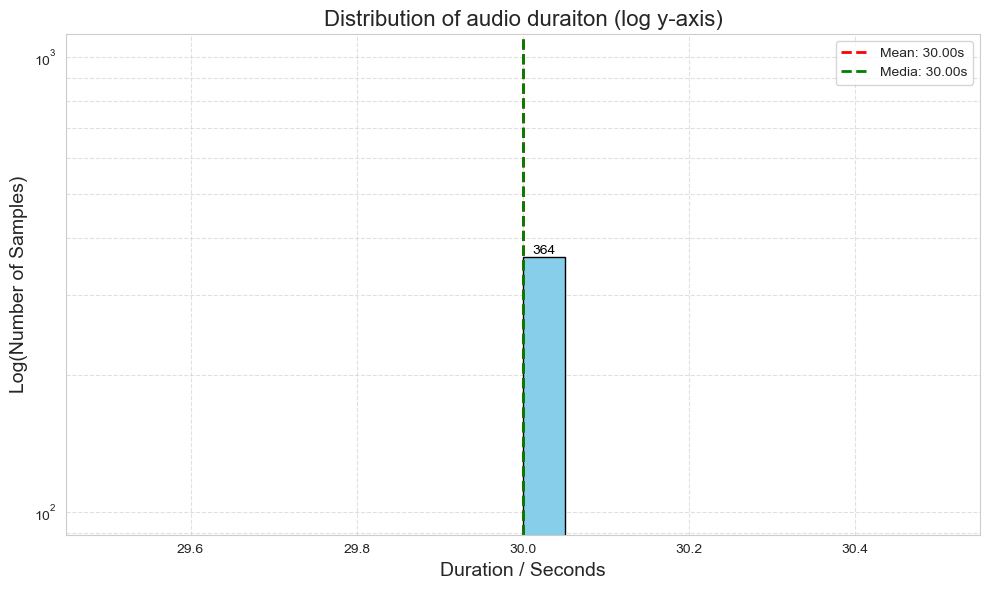

In [4]:
# ==================== Audio Data Analysis ============================= #
print('----- Audio Dataset analysis - sampling rate and sample length -----')

# set directory for audio files
if finetune_model:
    audio_dir = './genres_new_pers'
else: 
    audio_dir = './genres_original'

# init list for audio data    
audio_data = []

    
# get all audio data in to the list
for genre in sorted(os.listdir(audio_dir)):
    genre_path = os.path.join(audio_dir, genre)
    if not os.path.isdir(genre_path):
        continue 
    for filename in sorted(os.listdir(genre_path)):
        if filename.endswith('.wav'):
            file_path = os.path.join(genre_path, filename)
            try:
                y, sr = librosa.load(file_path, sr=None)  # load meta data of the audio
                audio_data.append({
                    'genre': genre,
                    'file_path': file_path,
                    'audio': y,
                    'sampling_rate': sr,
                    'n_samples': len(y),
                    'duration_sec': len(y) / sr
                })
            except Exception as e:
                print(f"Error loading {file_path}: {e}")

# change to pandas dataframe for easier handling
df_audio = pd.DataFrame(audio_data)

# Check audio dataframe
# print(df_audio.head())

# Samplingrate
print('Audio dataset sampling rate and number of occurences:')
print(df_audio['sampling_rate'].value_counts())


# calculate mean an median of the durations
mean_duration = np.mean(df_audio['duration_sec'])
median_duration = np.median(df_audio['duration_sec'])

# histogramm
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(df_audio['duration_sec'], bins=20, color='skyblue', edgecolor='black')

# log y-axis
plt.yscale('log')

# Get values of each bar and plot them on top
for count, patch in zip(n, patches):
    if count > 0: 
        plt.text(
            patch.get_x() + patch.get_width() / 2, 
            count,
            f'{int(count)}',
            ha='center',
            va='bottom',
            fontsize=10,
            color='black'
        )

# Median and mean
plt.axvline(mean_duration, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_duration:.2f}s')
plt.axvline(median_duration, color='green', linestyle='dashed', linewidth=2, label=f'Media: {median_duration:.2f}s')

# Achsentitel, Legende usw.
plt.title('Distribution of audio duraiton (log y-axis)', fontsize=16)
plt.xlabel('Duration / Seconds', fontsize=14)
plt.ylabel('Log(Number of Samples)', fontsize=14)
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


It can be seen that the sampling rate is 22050 Hz for all samples. The duration is for all samples of our own data 30 seconds. The durations of the GTZAN  dataset samples are mostly 30 seconds. A small amount is shorter and some are longer. The longer are from 30 to 30.6 seconds in small amounts. (The y is log-scaled so the distribution can be better seen.)

In [5]:
# ==================== Audio Data Analysis, Audio ============================= #
print('----- Audio Dataset analysis - Playable examples -----')

# Example samples for each genre
example_df = df_audio.groupby('genre').first().reset_index()

for idx, row in example_df.iterrows():
    print(f"Genre: {row['genre']}")
    display(Audio(data=row['audio'], rate=row['sampling_rate']))

----- Audio Dataset analysis - Playable examples -----
Genre: minihouse


Genre: proghouse


Genre: psytrance


Genre: trance


### 2.3 Image Analysis

In [6]:
# ==================== Image Data Analysis ============================= #
print('----- Dataset analysis - Classes and Samples -----')

# print size of data set per class
print('Dataset classes and index for classification:')
print(dataset.class_to_idx, '\n')
    
# prepare dict to count img per class
img_per_class = {class_: 0 for class_ in dataset.classes}

for i in dataset.imgs:
    img_path = i[0]
    class_folder = os.path.basename(os.path.dirname(img_path))
    if class_folder in img_per_class:
        img_per_class[class_folder] += 1

print('Number of samples per class:')
print(img_per_class)
if train_base_model:
    print("Class 'Jazz' only contains 99 samples, since one original .wav file was corrupted and removed from the dataset.")

if finetune_model: 
    print(f"Our dataset is slightly unbalaced. The genre Minimal House only contains {img_per_class['minihouse']} samples.")



----- Dataset analysis - Classes and Samples -----
Dataset classes and index for classification:
{'minihouse': 0, 'proghouse': 1, 'psytrance': 2, 'trance': 3} 

Number of samples per class:
{'minihouse': 88, 'proghouse': 92, 'psytrance': 92, 'trance': 92}
Class 'Jazz' only contains 99 samples, since one original .wav file was corrupted and removed from the dataset.
Our dataset is slightly unbalaced. The genre Minimal House only contains 88 samples.


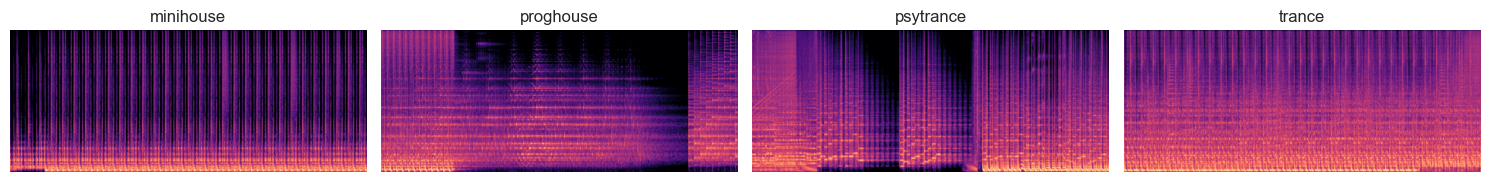

In [7]:
# ==================== Data Visualization ========================= #

# ========== Show one image per class
# Get subfolder names
subdir_data = sorted([
    name for name in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, name))
])

# inti plot
fig, axs = plt.subplots(3, 4, figsize=(15, 6))
axs = axs.flatten()  

for idx, dir in enumerate(subdir_data[:12]):  # max. 12 images
    dir_path = os.path.join(data_dir, dir)
    
    # get first image of each folder
    images = sorted([
        f for f in os.listdir(dir_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))
    ])
    
    if images:
        image_path = os.path.join(dir_path, images[5])
        img = mpimg.imread(image_path)
        axs[idx].imshow(img)
        axs[idx].set_title(dir)
        axs[idx].axis('off')
    else:
        axs[idx].set_visible(False)

# suppress empty axes
for j in range(idx + 1, len(axs)):
    axs[j].set_visible(False)

plt.tight_layout()
plt.show()


## 3. Data Preprocessing
### 3.1 Data Normalization
Firstly, mean and standard deviation of the data is calculated. This allows to normalize the data.

In [8]:
# ================ Preparation for data normalization ================ #

print('----- Data normalization started -----')
# Temporarly transformation without normalization
temp_transform = transforms.Compose([
    transforms.Resize((400, 1000)),
    transforms.ToTensor()
])

# load data set with temporal transform
temp_dataset = ImageFolder(data_dir, transform=temp_transform)

# create dataloader 
loader = DataLoader(temp_dataset, batch_size=64, shuffle=False)

# calculate mean and standard deviation
mean = 0.
std = 0.
total_images = 0

for images, _ in loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_images += batch_samples

mean /= total_images
std /= total_images

print("Dataset Mean:", mean)
print("Dataset Std:", std)

# Normalize data with calculated mean and std
# call function to transform data
transform = transforms.Compose([
    transforms.Resize((400, 1000)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

dataset = ImageFolder(data_dir, transform=transform)
print('----- Data normalization done -----')


----- Data normalization started -----
Dataset Mean: tensor([0.5145, 0.1687, 0.4212])
Dataset Std: tensor([0.2416, 0.1176, 0.1084])
----- Data normalization done -----


### 3.1 Dataloader, Subset and Stratified Splitting
Here, we will create a subset of the dataset with defined number of samples per class. The number of samples per class in the subset can be defined in the pre-settings. The subset is then split into a training and test set with stratified sampling. If no subset is created, the whole dataset is split into a training, validation and test set with stratified sampling. In the pre-settings is defined if the model is run on the subset or the whole dataset. 


In [9]:
# ================ Data preprocessing - Subset ======================= #
if use_subset:

    # Load a subset of the dataset*
    # criterion for subset, and  initialization
    class_counts = collections.defaultdict(int)
    max_per_class = max_per_class  # maximum number of spectrograms per genre
    genre_indices = []

    # Iterate through the dataset and select indices of spectrogram's*
    for idx, (img, label) in enumerate(dataset):
        if class_counts[label] < max_per_class:
            genre_indices.append(idx)
            class_counts[label] += 1
        # stopping criteria if all genres contain 10 spectrogram's
        if len(class_counts) == len(dataset.classes) and all(c >= max_per_class for c in class_counts.values()):
            break

    # created subset with the selected indices*
    subset_data = Subset(dataset, genre_indices)

    # Check Subset
    print("--------- Subset creation successful ----------")
    print(f"Spectrogram's in subset: {len(subset_data)}\n")

    # Train Ration
    train_ratio = training_ration

    # Collect indices and labels
    all_indices = list(range(len(subset_data)))
    all_labels = [subset_data[i][1] for i in all_indices]  # Integer-Labels

    # Stratified Split
    train_indices, test_indices = train_test_split(
        all_indices,
        train_size=train_ratio,
        stratify=all_labels,
        random_state=42  # for reproducibility
    )

    # create subsets
    train_subset = Subset(subset_data, train_indices)
    test_subset = Subset(subset_data, test_indices)

    # Create data loaders (load the train and validation into batches)
    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, generator=generator) # set the generator correctly to avoid device mismatches and runtime errors
    val_loader = DataLoader(test_subset, batch_size=32, shuffle=False, generator=generator) # set generator correctly


    # Print the number of samples in each set
    print("--------- Stratified Subset Data splitting successful ----------")
    print(f"Number of training samples: {len(train_subset)}")
    print(f"Number of testing samples: {len(test_subset)}\n")


# ================ Data preprocessing - Whole Dataset ======================= #
else:

    max_per_class = '100%'
    #  Extracting Tags
    targets = [dataset[i][1] for i in range(len(dataset))]  # assuming (x, label)

    # Stratified Split: 90% Train+Val, 10% Test
    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_set_size, random_state=42)
    for train_val_idx, test_idx in sss.split(X=targets, y=targets):
        pass

    # Stratified K-Fold on Train+Val (90%)
    train_val_targets = [targets[i] for i in train_val_idx]
    skf = StratifiedKFold(n_splits=5)
    batch_size = batch_size

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_idx, train_val_targets)):
        # Map indices back to original dataset
        train_indices = [train_val_idx[i] for i in train_idx]
        val_indices = [train_val_idx[i] for i in val_idx]

        train_targets = [targets[i] for i in train_indices]
        val_targets = [targets[i] for i in val_indices]

        # print(f"\nFold {fold+1}")
        # print("Train:", Counter(train_targets))
        # print("Validation:", Counter(val_targets))

        # Erstelle Subsets und Loader
        train_subset = Subset(dataset, train_indices)
        val_subset = Subset(dataset, val_indices)
        test_subset = Subset(dataset, test_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

    print("--------- Stratified whole Data splitting successful ----------")
    print(f"Number of training samples: {len(train_subset)}")
    print(f"Number of validation samples: {len(val_subset)}")
    print(f"Number of test samples: {len(test_subset)}\n")



--------- Subset creation successful ----------
Spectrogram's in subset: 80

--------- Stratified Subset Data splitting successful ----------
Number of training samples: 64
Number of testing samples: 16



## 4. Model Building and Training
### 4.1 Model Architecture
In this section three different model architectures are defined. The three models and their purposes are described here. Which model will be trained is defined in the pre-settings. 

**SimpelCNN** 

This model was the starting point and was used to try out code functionality during the whole project. It contains 4 blocks of convolutional layers and 3 fully connected layers. Each block consists of a Conv2D, ReLU and MaxPooling. For the convolutional layers the kernel is always set to 3 and the padding to 1, this ensures that the size is only changed through the pooling layers. The Channels of the convolutional layers are set to 16, 32, 64. 
 
**Extended SimpleCNN**

This model is based on the SimpleCNN architecture and is extended as far as it was possible that it still runs on a local computer.

The following things were added to the architecture, which resulted in increased performance: 
* Dropout: A rate of 0.2 after the two first fully connected layers could improve the model performance. 
* Batch Normalisation: A massive improvement could be achieved with Batch Normalisation. The Batch Normalisation was added after each convolutional layer as well as after the first two fully connected layers.


The following things were tried but didn't result in better performance or could not be run on local computer:
* Layer extension: a 5th convolutional block (Conv2d, ReLU, MaxPooling) brought no improvement. Deeper Network than that could not be run on local computer.
* Different Block Architecture: arrangements such as Conv2d, ReLU, Conv2d, ReLU, MaxPooling were tried but couldn't be run on local computer.

The evaluation of the model development is described in subsection 5.3.

**VGG19**

This architecture is based on the VGG19 model architecture. The purpose of this model was to train it on the Earth Cluster. Since this didn't work the model was not used but for the sake of completeness it is still presented here. The model consist of 5 convolutional blocks and 3 fully connected layers. The first two blocks have two convolutional layer with ReLU activation and MaxPooling at the end of each block. The three following layers have four convolutional layers with ReLU activation each and also MaxPooling at the end. With a kernel size of 3 and padding of 1 the layer also change only through MaxPooling (kernel size of 2 with stride 2). 
For the first two linear layers a dropout rate of 0.2 was applied to reduce overfitting. The last layer is the output layer with 10 classes.



In [10]:
# ================ Model building ======================= #

# SimpleCNN Network (Startingpoint)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(99200, 1024)
        self.fc2 = nn.Linear(1024, 128)
        self.fc3 = nn.Linear(128, num_classes)
        

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # (3x288x432) -> (16x144x216)    (3 x 400 x 1000) -> (16 x 200 x 500)
        x = self.pool(F.relu(self.conv2(x)))  # (16x144x216) -> (32x72x108)    (16 x 200 x 500) -> (32 x 100 x 250)
        x = self.pool(F.relu(self.conv3(x)))  # (32x72x108) -> (64x36x54)     (32 x 100 x 250) -> (64 x 50 x 125)
        x = self.pool(F.relu(self.conv4(x)))  # (64x36x54) -> (64x18x27)      (64 x 50 x 125 ) -> (64 x 25 x 62) = 99220
        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Extended SimpleCNN
class SimpleCNN_ext(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN_ext, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) 
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool4 = nn.MaxPool2d(2, 2)
        
        
        self.fc1 = nn.Linear(99200, 1024)
        self.bn5 = nn.BatchNorm1d(1024)
        
        self.fc2 = nn.Linear(1024, 128)
        self.bn6 = nn.BatchNorm1d(128)
        
        self.fc3 = nn.Linear(128, num_classes)
        
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))  # (3 x 400 x 1000)  -> (16 x 200 x 500) = 1'600'000
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))  # (16 x 200 x 500) -> (32 x 100 x 250) = 800'000
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))  # (32 x 100 x 250)  -> (64 x 50 x 125) = 400'000
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))  # (64 x 50 x 125 ) -> (64 x 25 x 62) = 99'200
        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.bn5(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn6(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x




class VGG19(nn.Module):
    def __init__(self, num_classes):
        super(VGG19, self).__init__()

        # Block 1
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # H/2

        # Block 2
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # H/4

        # Block 3
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv3_3 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv3_4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # H/8

        # Block 4
        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv4_3 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv4_4 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)  # H/16

        # Block 5
        self.conv5_1 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_3 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_4 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)  # H/32

             
        self.fc1 = nn.Linear(512 * 12 * 31, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, num_classes)

        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = self.pool1(x)

        # Block 2
        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        x = self.pool2(x)

        # Block 3
        x = F.relu(self.conv3_1(x))
        x = F.relu(self.conv3_2(x))
        x = F.relu(self.conv3_3(x))
        x = F.relu(self.conv3_4(x))
        x = self.pool3(x)

        # Block 4
        x = F.relu(self.conv4_1(x))
        x = F.relu(self.conv4_2(x))
        x = F.relu(self.conv4_3(x))
        x = F.relu(self.conv4_4(x))
        x = self.pool4(x)

        # Block 5
        x = F.relu(self.conv5_1(x))
        x = F.relu(self.conv5_2(x))
        x = F.relu(self.conv5_3(x))
        x = F.relu(self.conv5_4(x))
        x = self.pool5(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


### 4.2 Training Loop
In this section the training loop is defined. For each epoch, the model trains on the training set and evaluates on the validation set. It computes training and validation loss as well as accuracy per epoch. It stores metrics and training time for each epoch in a log. The validation loss is monitored to prevent overfitting. If the validation loss doesn't improve for a number of consecutive epochs (defined by patience), training stops early. The model state with the best validation performance is saved and restored after training. In the pre-setting the number of epochs can be defined. 

In [11]:
# ================ Training Loop ======================= #

# init epochs for summary file export (such that ran epochs are stated as well as epochs defined in the pre-settings)
epochs_ran = 1


def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience=5):
    ''' 
                    
    :param model: the neural network to train.
    :param train_loader: data loader
    :param val_loader: data loader
    :param criterion: loss function
    :param optimizer: optimizer for backpropagation
    :param num_epochs: maximum number of epochs
    :param patience: how many epochs to wait before stopping early if no improvement is seen
    :return: A pandas DataFrame containing training logs (loss, accuracy, time) for each epoch
    '''
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    training_logs = []
    
    for epoch in range(num_epochs):
        start_time = time.time()

        # --- Training ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # for images, labels in tqdm(train_loader, desc = f'Training Epoch {epoch + 1}', leave = True):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # --- Evaluation ---
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            # for images, labels in tqdm(val_loader, desc="Validierung", leave=True):
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = correct / total
        epoch_time = time.time() - start_time

        # --- Logging ---
        training_logs.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "epoch_time_sec": epoch_time
        })        # --- Logging ---
        training_logs.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "epoch_time_sec": epoch_time
        })

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Validation Loss: {val_loss:.4f}, Validation Acc: {val_acc:.4f} | "
              f"Time: {epoch_time:.2f}s")

        # --- Early Stopping Check ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"EarlyStopping patience counter: {patience_counter} out of {patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
        epochs_ran = epoch + 1
        
    # Set model back to best state
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    
    logs_df = pd.DataFrame(training_logs)
    
    # reset parameters for hyperparameter tuning 
    if tune_hyperparams:
        best_val_loss = float('inf')
        best_model_state = None
        patience_counter = 0
    return logs_df, epochs_ran



### 4.2 Training and Hyperparameter Tuning
Depending on the pre-settings the model is trained regularly or a hyperparameter tuning is performed. 
With hyperparameter tuning the best hyperparameters out of a selection could be determined. Different learning rates and batch sizes were tested. The best hyperparameters are then used for the final training of the model. 
The results from the hyperparameter tuning and its evaluation can be seen in subsection 5.2.


In [12]:
# ========== Hyperparameters, Model initialization and Training ============ #

num_classes = len(dataset.classes)

if train_base_model:
    if tune_hyperparams:
        # ========== Hyperparameters
        learning_rates = [0.01, 0.001, 0.0001]
        batch_size = [16, 32, 64]
        optimizers = ['Adam',]
        criterion = nn.CrossEntropyLoss()
        num_epochs = 50
    
        # Initialize lists to store results
        all_logs = []
    
        # ========== Training loop over all Hyperparameters
        print(f"--------- Training loop started, {num_epochs} epochs  ----------")
        # Loop through hyperparameters
        for i, lr in enumerate(learning_rates):
            for j, bs in enumerate(batch_size):
                for k, opt_name in enumerate(optimizers):
    
                    set_seed(42)
                    if use_VGG19:
                        model = VGG19(num_classes).to(device)
                    else:
                        model = SimpleCNN_ext(num_classes).to(device)
                    print(f"Training with Learning Rate: {lr}, Batch Size: {bs}, Optimizer: {opt_name}")
    
                    if opt_name == 'Adam':
                        optimizer = optim.Adam(model.parameters(), lr=lr)
                    elif opt_name == 'SGD':
                        optimizer = optim.SGD(model.parameters(), lr=lr)
    
                    # Create DataLoader with the current batch size
                    train_loader = DataLoader(train_subset, batch_size=bs, shuffle=True)
                    val_loader = DataLoader(test_subset, batch_size=bs, shuffle=False)
    
                    # Train the model with the current hyperparameters
                    logs_df, epochs_ran = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs)
    
                    # Add hyperparameter information to logs_df
                    logs_df["learning_rate"] = lr
                    logs_df["batch_size"] = bs
                    logs_df["optimizer"] = opt_name
    
                    # Append logs_df to the list
                    all_logs.append(logs_df)
                    print("Hyperparameter tuning run finished.\n")
    
        # Count Layers
        num_Conv_layers = str(model).count("Conv")
        num_linear_layers = str(model).count("Linear")
    
        # Combine all logs into a single DataFrame
        final_logs_df = pd.concat(all_logs, ignore_index=True)
    
    
    else:
        # Device
        set_seed(42)
        if use_VGG19:
            model = VGG19(num_classes).to(device)
        else:
            model = SimpleCNN_ext(num_classes).to(device)
    
        print("--------- Model building successful ----------")
        print(model, '\n')
    
        # Loss and optimizer
        criterion = nn.CrossEntropyLoss()
        lr = learning_rate
        optimizer = optim.Adam(model.parameters(), lr=lr)
    
    
        print("--------- Model and Hyperparameter initialization successful ----------")
        print(f'Criterion: {criterion}')
        print(f'Optimizer: {optimizer}')
        print(f'Learning Rate: {lr}\n')
    
        # reasign epoch to the pre-set value
        num_epochs = epochs
    
        print(f"--------- Training loop started, {num_epochs} epochs  ----------")
    
        # Training
        logs_df, epochs_ran = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs)
        print("Training loop finished.\n")
    
        # Count Layers
        num_Conv_layers = str(model).count("Conv")
        num_linear_layers = str(model).count("Linear")

--------- Model building successful ----------
SimpleCNN_ext(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPoo

### 4.3 Finetuning with own pretrained model

In [15]:
# ================= Finetuning with own pretrained model ======================= #

if finetune_model: 
    # load pretrained model
    model = SimpleCNN_ext(num_classes=10)
    model.load_state_dict(torch.load("SimpleCNN_ext_pretrained.pth"))
    model.fc3 = nn.Linear(model.fc3.in_features, num_classes)  # num_classes = 4
    model.to(device)
    
    # Option to only train the classifier and freeze the feature extractor
    if only_finetune_classifier: 
        # Freeze the feature extractor
        for param in model.parameters():
            param.requires_grad = False
        
        # only train classifier
        for param in model.fc3.parameters():
            param.requires_grad = True
            
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    lr = learning_rate
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    print("--------- Model and Hyperparameter initialization successful ----------")
    print(f'Criterion: {criterion}')
    print(f'Optimizer: {optimizer}')
    print(f'Learning Rate: {lr}')
    print(f'Only Classifier: {only_finetune_classifier}\n')
    
    # Training loop
    num_epochs = epochs

    print(f"--------- Training loop started, {num_epochs} epochs  ----------")

    # Training
    logs_df, epochs_ran = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs)
    print("Training loop finished.\n")
    
    # Count Layers
    num_Conv_layers = str(model).count("Conv")
    num_linear_layers = str(model).count("Linear")

    

/var/folders/yy/vt37z5vs2x579x1sf4g7clhm0000gn/T/ipykernel_23796/1205231294.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("SimpleCNN_e

--------- Model and Hyperparameter initialization successful ----------
Criterion: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Learning Rate: 0.001
Only Classifier: True

--------- Training loop started, 10 epochs  ----------
Epoch [1/10] Train Loss: 1.5047, Train Acc: 0.2188 | Validation Loss: 1.3660, Validation Acc: 0.1250 | Time: 17.17s
Epoch [2/10] Train Loss: 1.3947, Train Acc: 0.2812 | Validation Loss: 1.3298, Validation Acc: 0.1250 | Time: 11.75s
Epoch [3/10] Train Loss: 1.4321, Train Acc: 0.2812 | Validation Loss: 1.3012, Validation Acc: 0.2500 | Time: 12.03s
Epoch [4/10] Train Loss: 1.2965, Train Acc: 0.3750 | Validation Loss: 1.2789, Validation Acc: 0.2500 | Time: 12.27s
Epoch [5/10] Train Loss: 1.2657, Train Acc: 0.4375 | Validation Loss: 1.2592, Validation Acc: 0.3750 | 

### 4.4 Transferlearning with foreign pretrained models

As pretrained models the following models were tested: 
- VGG16 / VGG19, finetuning  with full dataset did not succeed on local machine due to computational limits
- ResNet50 finetuning  with full dataset did not succeed on local machine due to computational limits
- ResNet18
- MobileNet_v2

Finetuning of the pretrained models was only possible with reduced number of samples. 50 Samples per class were used. This worked fine for ResNet18 and MobileNet_v2.

In [16]:
# ================ Load and prepare foreing Pretrained models ======================= #
#  Import pretrained models from pytorch
vgg16 = models.vgg16(pretrained = True)
vgg19 = models.vgg19(pretrained = True)
resnet18 = models.resnet18(pretrained = True)
resnet50 = models.resnet18(pretrained = True)
mobilenet_v2 = models.mobilenet_v2(pretrained=True)


# change last layer of the models to suit the classes of our own data
vgg16.classifier[6] = nn.Linear(4096, num_classes)
vgg19.classifier[6] = nn.Linear(4096, num_classes)
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)
mobilenet_v2.classifier[1] = nn.Linear(mobilenet_v2.last_channel, num_classes)


# Option to only train the classifier and freez the feature extractor
if only_finetune_classifier: 
    for param in vgg16.parameters():
        param.requires_grad = False
    for param in vgg16.classifier[6].parameters():
        param.requires_grad = True
        
    for param in vgg19.parameters():    
        param.requires_grad = False 
    for param in vgg19.classifier[6].parameters():
        param.requires_grad = True
        
    for param in resnet18.parameters():
        param.requires_grad = False
    for param in resnet18.fc.parameters():
        param.requires_grad = True
        
    for param in resnet50.parameters():
        param.requires_grad = False
    for param in resnet50.fc.parameters():
        param.requires_grad = True
        
    for param in mobilenet_v2.parameters():
        param.requires_grad = False
    for param in mobilenet_v2.classifier[1].parameters():
        param.requires_grad = True
    

/opt/miniconda3/envs/NNandDL/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/NNandDL/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/opt/miniconda3/envs/NNandDL/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weight

Here the foreing pretrained model is finetuned. The chosen model needs to be uncommented where the others have to be commented out.

In [17]:
# ================ Training foreign pretrained models ======================= #

if finetune_pretrained: 
    # choose model to finetune
    # model = mobilenet_v2
    model = resnet18
    # model = resnet50
    # model = vgg16
    # model = vgg19
    model.to(device)
    
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    lr = learning_rate
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    print("--------- Model and Hyperparameter initialization successful ----------")
    print(f'Criterion: {criterion}')
    print(f'Optimizer: {optimizer}')
    print(f'Learning Rate: {lr}')
    print(f'Only Classifier: {only_finetune_classifier}\n')
    
    # Training loop
    num_epochs = epochs

    print(f"--------- Training loop started, {num_epochs} epochs  ----------")

    # Training
    logs_df, epochs_ran = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs)
    print("Training loop finished.\n")
    
    # Count Layers
    num_Conv_layers = str(model).count("Conv")
    num_linear_layers = str(model).count("Linear")

### 4.4 Evaluation of the trained model and data export
In this section the model that is trained above is evaluated. What the plots and data show is dependent on the pre-settings. The plots allways correspond to the last trained model. The plots and training data can (depending on the pre-settings) be exported to png and txt files for later evaluation and interpretation. 

**Accuracy and Loss**

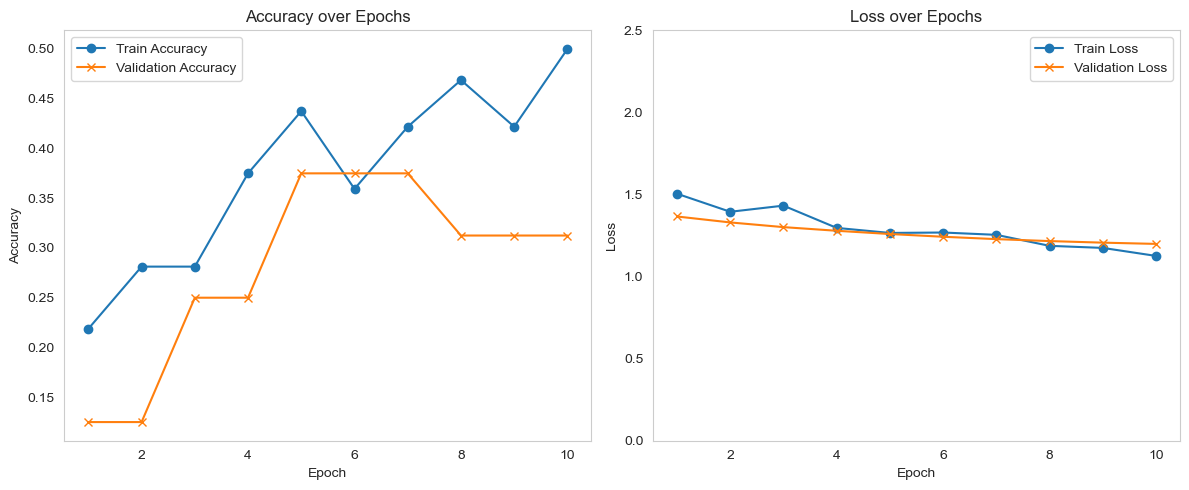

In [18]:
# ================ Plot training process ======================= #

# init plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Accuracy subplot ---
axes[0].plot(logs_df["epoch"], logs_df["train_accuracy"], label="Train Accuracy", marker='o')
axes[0].plot(logs_df["epoch"], logs_df["val_accuracy"], label="Validation Accuracy", marker='x')
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(False)

# --- Loss subplot ---
axes[1].plot(logs_df["epoch"], logs_df["train_loss"], label="Train Loss", marker='o')
axes[1].plot(logs_df["epoch"], logs_df["val_loss"], label="Validation Loss", marker='x')
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_ylim(0, 2.5)
axes[1].legend()
axes[1].grid(False)

plt.tight_layout()

# Optional: Save Plot to file
if save_plot_files:
    filename_acc_loss = os.path.join(script_directory, f"{date.today().strftime('%y%m%d')}_Acc-Loss_conv{num_Conv_layers}_lin{num_linear_layers}_ep{num_epochs}_lr{lr}.png")
    plt.savefig(filename_acc_loss, dpi=600)
    print(f"  - Progression Plots saved to file: {filename_acc_loss}")

if show_plot_files:
    plt.show()

**Classification Report and Confusion Matrix**

To plot the clf and the cm the predictions for the test-dataset have to be saved first.

In [19]:
# ================ Save Model Predictions ======================= #
def save_predictions(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    y_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)  # raw logits
            probs = F.softmax(outputs, dim=1)  # Probabilities
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())  # list of lists

    return np.array(y_true), np.array(y_pred), np.array(y_probs)

if use_subset:
    test_loader = val_loader
y_true, y_pred, y_probs = save_predictions(model, test_loader)

# Extract labels and classification report
label_idx = [dataset.class_to_idx[i] for i in dataset.classes]
clf_report = classification_report(y_true, y_pred, labels=label_idx, target_names=dataset.classes, output_dict=True, zero_division=1)

Now the clf and the cm can be displayed.

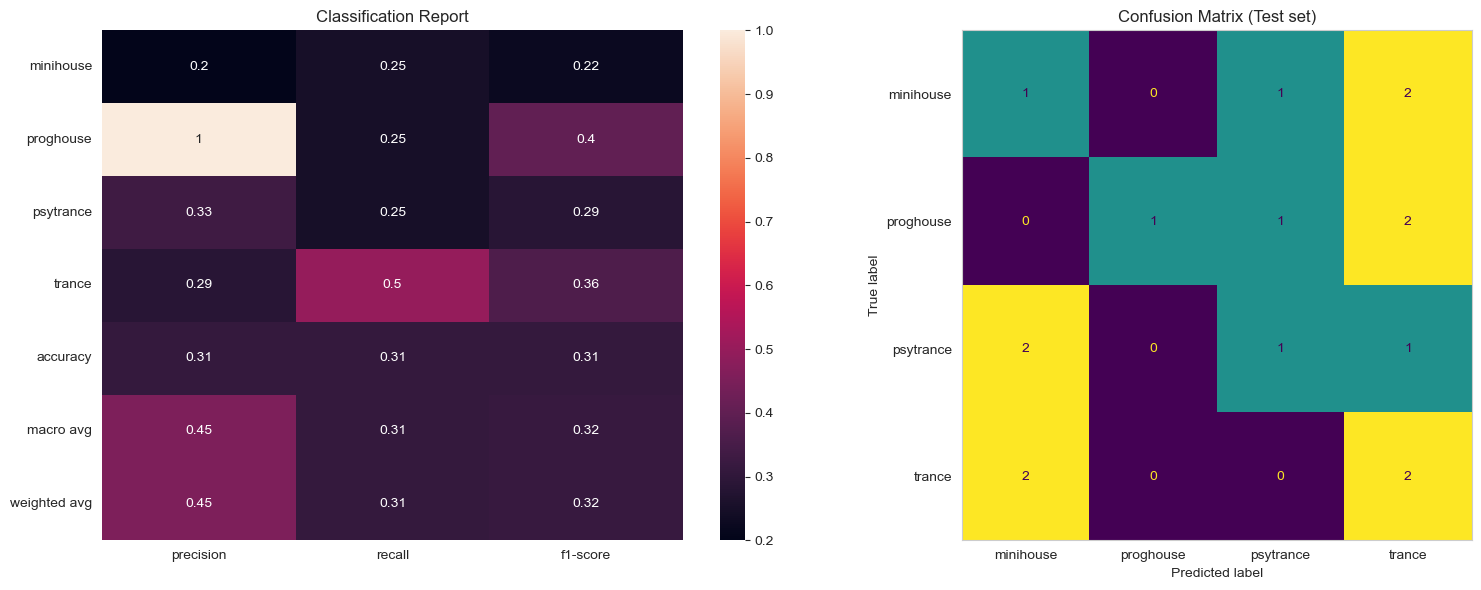

In [20]:
# ================ Plot clf & cm of test data set ======================= #

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=label_idx)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Classification Report Heatmap
sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True, ax=ax1)
ax1.set_title('Classification Report')

# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
disp.plot(ax=ax2, colorbar=False)  # Avoid duplicate colorbars
ax2.set_title('Confusion Matrix (Test set)')
ax2.grid(False)

plt.tight_layout()

# Optional save plot to file
if save_plot_files:
    filename_clf_cm = os.path.join(script_directory, f"{date.today().strftime('%y%m%d')}_clf-cm_conv{num_Conv_layers}_lin{num_linear_layers}_ep{num_epochs}_lr{lr}.png")
    plt.savefig(filename_clf_cm, dpi=600)
    print(f"  - Analytical Plots saved to file: {filename_clf_cm}")

if show_plot_files:
    plt.show()

**ROC-AUC**


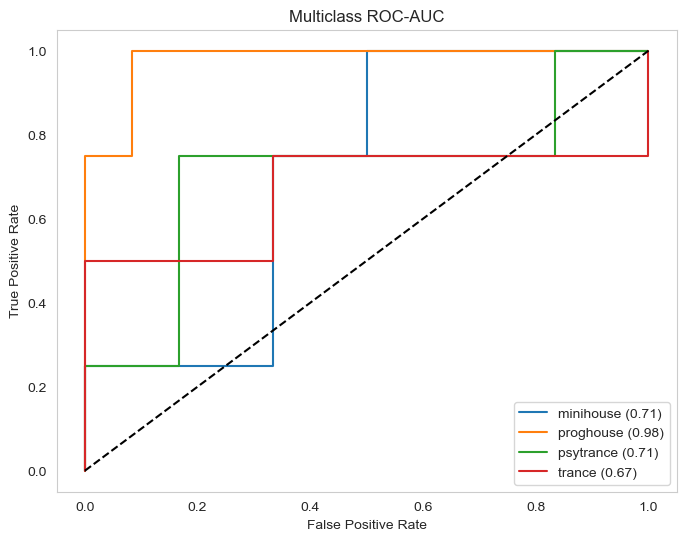

In [21]:
# ================= Prepare Data ======================= #
# Classes
classes = np.unique(y_true)
n_classes = len(classes)
class_names = dataset.classes

# Binarize y_true
y_true_bin = label_binarize(y_true, classes=classes)

# ROC-AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ================= Plot ROC-AUC ======================= #
# Plot
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} ({roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC-AUC")
plt.legend()
plt.grid()

# Optional save plot to file
if save_plot_files:
    filename_roc = os.path.join(script_directory, f"{date.today().strftime('%y%m%d')}_ROC-AUC_conv{num_Conv_layers}_lin{num_linear_layers}_ep{num_epochs}_lr{lr}.png")
    plt.savefig(filename_roc, dpi=600)
    print(f"  - ROC-AUC Plot saved to file: {filename_roc}")

if show_plot_files:
    plt.show()

**PR-AUC**


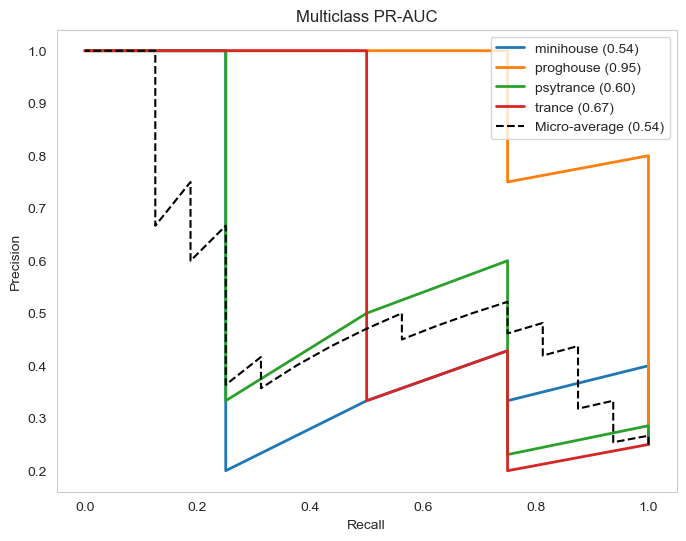

In [22]:
# =================== Prepare Data ======================= #

# PR-AUC for each class
precision = dict()
recall = dict()
average_precision = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    average_precision[i] = average_precision_score(y_true_bin[:, i], y_probs[:, i])

# Micro-average over all classes
precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_bin.ravel(), y_probs.ravel())
average_precision["micro"] = average_precision_score(y_true_bin, y_probs, average="micro")


# =================== Plot PR-AUC ======================= #
# Plot
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(recall[i], precision[i], lw=2,
             label=f"{class_names[i]} ({average_precision[i]:.2f})")

plt.plot(recall["micro"], precision["micro"], linestyle='--', color='black',
         label=f"Micro-average ({average_precision['micro']:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multiclass PR-AUC")
plt.legend(loc="best")
plt.grid()
# Optional save plot to file
if save_plot_files:
    filename_pr = os.path.join(script_directory, f"{date.today().strftime('%y%m%d')}_PR-AUC_conv{num_Conv_layers}_lin{num_linear_layers}_ep{num_epochs}_lr{lr}.png")
    plt.savefig(filename_pr, dpi=600)
    print(f"  - ROC-AUC Plot saved to file: {filename_pr}")

if show_plot_files:
    plt.show()

Save ROC- and PR-AUC data to files

In [23]:
# ================= Save ROC- and PR-AUC Data to file ======================= #
    
if save_summary_txt:
    filename_auc = os.path.join(script_directory, f"{date.today().strftime('%y%m%d')}_AUC-Data_conv{num_Conv_layers}_lin{num_linear_layers}_ep{num_epochs}_lr{lr}.txt")

    # Open file to write data
    with open(filename_auc, "w") as f:
        # Header
        f.write(f"{'Genre':<14}{'ROC-AUC':<14}{'PR-AUC':<14}\n")
        
        # Iteration over values and write to file
        for genre, roc, pr in zip(class_names, roc_auc.values(), average_precision.values()):
            f.write(f"{genre:<14}{roc:<14.4f}{pr:<14.4f}\n")

    print(f"  - ROC-AUC and PR-AUC Data saved to file: {filename_auc}")

Export Training Logs: The training logs and the model itself is exported. Additionally, an overview over the training and the model can be saved to a text file.

In [24]:
# ================ Saving Model files and logs ======================= #
print("\n--------- Saving files: ----------")
if not save_model_data: 
    print("File saving deactivated...")
    
# Optional: Convert to DataFrame and save
if save_model_data and not tune_hyperparams:
    filename_logs = os.path.join(script_directory, f"{date.today().strftime('%y%m%d')}_Train-log_conv{num_Conv_layers}_lin{num_linear_layers}_ep{num_epochs}_lr{lr}.csv")
    logs_df.to_csv(filename_logs, index=True)
    print(f"  - Training log saved to file: {filename_logs}")

# Save the combined DataFrame to a CSV file of hyperparameter tuning
if save_model_data and tune_hyperparams:
    filename_all_logs = os.path.join(script_directory,
                                     f"{date.today().strftime('%y%m%d')}_Hyper-Train-log_conv{num_Conv_layers}_lin{num_linear_layers}_ep{num_epochs}_lr{lr}.csv")
    final_logs_df.to_csv(filename_all_logs, index=False)
    print(f"  - Hyperparameter results saved to file: {filename_all_logs}")

# Optional: Save the model
if save_our_model:
    filename_model = os.path.join(script_directory, f"{date.today().strftime('%y%m%d')}_Model_conv{num_Conv_layers}_lin{num_linear_layers}_ep{num_epochs}_lr{lr}.pth")
    torch.save(model.state_dict(), filename_model)
    print(f"  - Model saved to file: {filename_model}")
    


--------- Saving files: ----------
File saving deactivated...


Export Training Logs


In [25]:
# ================ Save Model summary to text file ======================= #
def save_model_summary(model, filepath="model_summary.txt", epochs=None, lr=None, optimizer=None, batch_size=None,
                       device=None, max_per_class='100%', epoch_times=None, epochs_ran=None):
    with open(filepath, "w") as f:
        f.write("--- Model Architecture ---\n")
        f.write(str(model))
        f.write("\n\n--- Hyperparameters ---\n")
        if epochs is not None and epochs_ran is not None:
            f.write(f"Epochs: {epochs_ran}/{epochs}\n")
        if lr is not None:
            f.write(f"Learning Rate: {lr}\n")
        if optimizer is not None:
            f.write(f"Optimizer: {optimizer.__class__.__name__}\n")
        if batch_size is not None:
            f.write(f"Batch Size: {batch_size}\n")
        if device is not None:
            f.write(f"Device: {device}\n")
        if max_per_class is not None:
            f.write(f"Subset size: {max_per_class}\n")

        if epoch_times is not None:
            total_time = sum(epoch_times)
            f.write(f"\n--- Runtime ---\n")
            f.write(f"Total training time: {total_time:.2f} seconds\n")
            f.write(f"Mean training time: {total_time / epochs_ran:.2f} seconds/epoch\n")

        f.write("\n--- Parameters ---\n")
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        f.write(f"Total parameters: {total_params}\n")
        f.write(f"Trainable parameters: {trainable_params}\n")


filename_model_summary = os.path.join(script_directory, f"{date.today().strftime('%y%m%d')}_Model-Summary_conv{num_Conv_layers}_lin{num_linear_layers}_ep{num_epochs}_lr{lr}.txt")
epoch_times = logs_df['epoch_time_sec']

# Optional Export of Model and Training Summary
if save_summary_txt:
    print("\n--------- Saving files: ----------")
    save_model_summary(model,
                       filepath=filename_model_summary,
                       epochs=num_epochs,
                       lr=lr,
                       optimizer=optimizer,
                       batch_size=batch_size,
                       device=device,
                       max_per_class=100,
                       epoch_times=epoch_times, 
                       epochs_ran = epochs_ran)
    print(f"  - Model Summary saved to file: {filename_model_summary}")
else: 
    print("\n--------- Saving files: ----------")
    print("File saving deactivated...\n")


--------- Saving files: ----------
File saving deactivated...



## 5. Evaluation
In this chapter the final model, the hyperparameter tuning, the model development and the finetuning is evaluated and disscussed. Also, the pretrained models (which are finetuned) and our own finetuned model are compared.


### 5.1 Evaluation of the developed model
Here, the final developed model is evaluated. Its development is further described in subsection 5.3.

**Training Process**

In [30]:
#**Training Process**

HTML('<img src="./Plots_Base_Model/250516_Acc-Loss_conv4_lin3_ep100_lr0.001.png" width="1250"/>')

**Interpretation of the training process**

In blue we plotted the performance of the training and in orange the validation set. The left plot shows the accuracy over 10 epochs and the right plot shows the loss over epochs.

*Accuracy*

The validation accuracy increases steadily over the epochs. It reaches its maximum close to 1 after epoch 6. This indicates that our model is learning well on training data.
The validation accuracy increases and then starts fluctuating after a drop at epoch 4. It stabilizes after epoch 8 but does not increase further. This hints that our model does not generalize sufficiently for unseen data. The discrepancy between the training and validation accuracy indicates that the model starts to overfit on the training data after epoch 5.

*Validation*

The blue line shows a consistent decrease in loss, reaching close to zero by epoch 10. This indicates that the model is fitting the training data very well.
The validation loss (orange) also decreases initially but then shows an increase also at epoch 4 and continues to fluctuate around 1 after that. This also indicates potential overfitting.


**Clf and CM**


In [31]:
HTML('<img src = "./Plots_Base_Model/250516_clf-cm_conv4_lin3_ep100_lr0.001.png", width="1250"/>')

**Interpretation of the cfl plot:**

In the Classification Report we see the precision, recall as well as the F1-score (3) which is the harmonic mean of both. High precision indicates low false positive rate (1) whereas high recall indicates low false negative rate (2). In the confusion matrix false positives are all vertical entries for a given label. In the rows false negatives predictions can be found. Together with the true positives on the diagonal of the confusion matrix, precision and recall of this classification report plot can be calculated for each genre.

$$\begin{align}
\text{precision} &= \frac{\text{true positive rate}}{\text{true positive rate + false positive rate}} \tag{1} \\
\text{recall} &= \frac{\text{true positive rate}}{\text{true positive rate + false negative rate}} \tag{2} \\
\text{F1-score} &= 2 \cdot \frac{\text{precision} \cdot \text{accuracy}}{\text{precision + accuracy}} \tag{3}
\end{align}$$


We also added the accuracy (4) as well as the macro and weighted average for each column.
$$\text{accuracy} = \frac{\text{true positive rate + true negative rate}}{\text{N}} \tag{4}$$
Note: N = 100 in our case because we tested with 10 spectograms per genre.

We can see that for pop for example the precision is 1 which means that the model is able to predict all given pop samples as pop (no vertical entries). But the recall is very small (many entries on horizontal row) resulting in a low F1-score. This shows that high precision or recall alone respectively is not enough in and of itself. Therefore, F1-scores are a more robust measure accounting for both measures.

The over all average for precision of our model is 0.76, for recall it's 0.67 and the overall F1-score is 0.64.
A precision of 0.76 means that the model classifies 76% of testing samples right among all others. With a recall of 0.67 the model predicts 67% of all.

Conclusions
The model performs well for some genres (e.g., classical, metal, reggae) with high precision and recall.
For other genres (e.g., country, pop, rock), the model either misses many actual instances (low recall) or has many false positives (low precision).
The overall accuracy is moderate, suggesting room for improvement in the model's performance.
The balance between precision and recall varies significantly across genres, indicating that the model may need further tuning or additional data to improve its performance for certain classes.

**Interpretation of the cm plot:**

A more detailed model performance evaluation measure is the confusion matrix plot. The classification report is Based on these measures.

Diagonal cells represent correct predictions by the model (true positives for each genre). Non-zero entries in off-diagonal cells show misclassifications (false positives and false negatives). High values indicate that the model confuses one genre with another.
For the genres hiphop, disco and jazz the true positives predicted by our model is the highest.

The model performs well for certain genres, with high accuracy and minimal misclassifications. For other genres, the model struggles, indicating areas for improvement. The confusion matrix helps identify specific genres where the model's performance can be enhanced through better feature selection, more training data, or model tuning.

The good performance of this model visible by these plots mainly informed our choice of this model for further analysis and comparison to pre-trained models in chapter 5.5. There, we compare the performance of this fine tuned model with MobileNet_v2 and ResNet18.

**ROC-AUC**

In [32]:
HTML('<img src = "./Plots_Base_Model/250516_ROC-AUC_conv4_lin3_ep100_lr0.001.png", width="900"/>')

**Interpretation of the ROC-AUC plot:**

We used a Receiver operating characteristics (ROC) curve plot to asses the performance of our base model with batch normalization (our final model). The area under the curve (AUC) allows to evaluate the model performance of a binary classifier. It's displayed for every genre in the legend. Larger AUC values indicate better model performance. For a perfect model the AUC would be 1. In contrast, for random guessing we would have AUC = 0.5.

Since we are having a multiclass classification problem, we reduced the complexity of its analysis by reducing it to a binary classification problem for each genre. We therefore predict for each spectogram if it is the respective genre or not (yes/no = 1/0).

The above plot shows the false positive rate against the true positive rate for training and validation over the ran epochs (10) with a learning rate of 0.001 and a batch size of 16. The rates are recalculated for several different thresholds using the following formula:

$$
\begin{equation}
\text{AUC} = \sum_{i=1}^{n-1} \left( \frac{1}{2} \times (FPR_{i+1} - FPR_i) \times (TPR_{i+1} + TPR_i) \right),
\tag{5}
\end{equation}
$$
where $FPR_{i+1}, FPR_{i}$ and $TPR_{i+1}, TPR_{i}$ are false positive rates and true positive rates of consecutive thresholds.



High-performance genres are classical, hiphop, jazz, metal and disco with an AUC range of 0.98 - 0.99.
Moderate-performing genres are reggae and pop where the AUC was 0.91 and 0.97. Country and rock performed moderately with an AUC of 0.84 and 0.86 respectively.

The lower recall and higher miscalssification rates that the AUC score is based upon in the moderately AUC genres is also reflected in the previous two plots. Interestingly, rock, country and pop had a moderate to high precision rate and a low recall. This means that these genres are not well recognised by the model and therefore often misclassified.


**PR-AUC**

In [33]:
HTML('<img src = "./Plots_Base_Model/250516_PR-AUC_conv4_lin3_ep100_lr0.001.png", width="625"/>')

**Interpretation of the PR-AUC plot:**

We used a precision-recall (PR) curve plot to asses the performance of our base model with batch normalization. The area under the curve (AUC) allows to evaluate the model performance of a binary classifier. Larger PR AUC values indicates better model performance. Since we are having a multiclass classification problem, we reduced the complexety by reducing it to a binary classification problem for each genre. We therefore predict for each spectogram if it is the respective genre or not (yes/no = 1/0).

The above plot shows the recall and precision for training and validation over the ran epochs (100) with a learning rate of 0.001 and a batch size of 16.
The legend shows the exact PR AUC values for each genre. At the very least we also included the micro-average across all genres.
Compared to the ROC-AUC plot above in absolute values this measure is spread over a broader range. Relatively speaking the different genres performed similarly. For example classical, hiphop and jazz performed the highest and still have high values here (0.87-0.93). Previously moderately performing genres (pop, raggae) are around average here. Country and rock performed the worst compared to the others. Rock has a lower score in absolute values compared to country.
The three genres that were the least often correctly identified in the confusion matrix (CM) were country, pop, rock. It's also these genres that perform below average here.
All in all, this plot also verifies what we have already concluded previously.


### 5.2 Evaluation of Hyperparameter Tuning
The hyperparameter tuning was performed with the following hyperparameters:
- Learning Rates: 0.01, 0.001, 0.0001
- Batch Sizes: 16, 32, 64
- Optimizers: Adam

In pre runs it could be found that the SGD optimizer was not able to perform valuable training and was therefore neglected in the hyperparameter tuning. The model architecture was relatively simple and was build as follows: 

  * (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  * (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  * (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  * (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  * (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  * (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  * (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  * (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  * (fc1): Linear(in_features=99200, out_features=1024, bias=True)
  * (fc2): Linear(in_features=1024, out_features=128, bias=True)
  * (fc3): Linear(in_features=128, out_features=10, bias=True)
  
For the training the maximum epochs were set to 50, but none of the parameter combinations could exceed the set epochs. Through early stopping the training was stopped after 5 epochs without improvement of the validation loss. For the training only 50% of the data was used due to scarcity of computational power. The whole hyperparameter tuning took around 8 hours and 20 minutes. 
For analysis accuracy (train and val), loss (train and val), time per epoch, ran epochs, and the tuning parameters were recorded. 

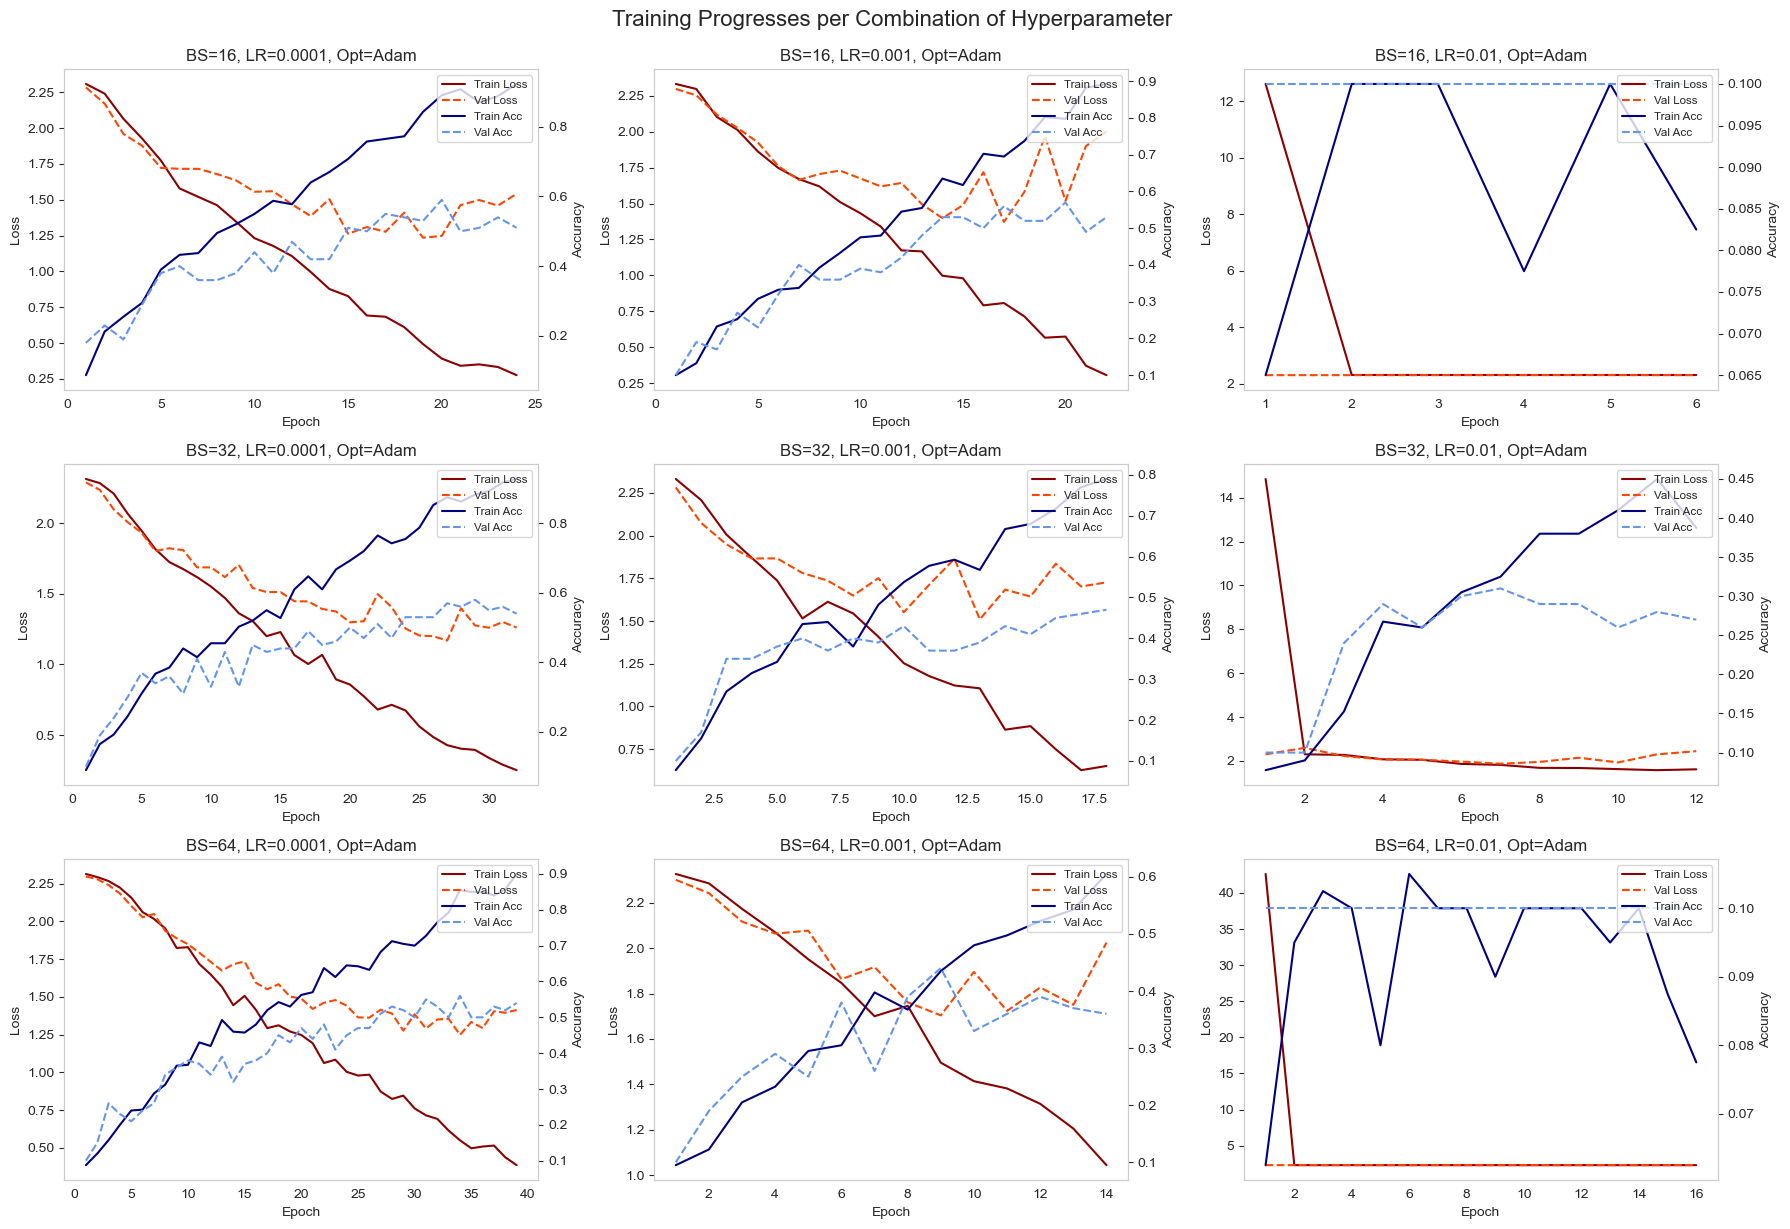

In [34]:
# ================ Load CSV data of hyperparameter tuning ======================= #
# Load CSV data
df = pd.read_csv('./HyperparaTuning_logs.csv', delimiter = ';')


# Group for hyperparameters
group_cols = ['batch_size', 'learning_rate', 'optimizer']
groups = df.groupby(group_cols)

# Prepare 3 x 3 grid for subplots
ncols = 3
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 12))
axes = axes.flatten()

# Set colors for plotting
colors = {
    'train_loss': 'darkred',
    'val_loss': 'orangered',
    'train_accuracy': 'navy',
    'val_accuracy': 'cornflowerblue'
}

for idx, ((batch_size, lr, opt), group) in enumerate(groups):
    if idx >= 9:
        break 

    ax = axes[idx]
    
    # Sort the group by epoch
    group_sorted = group.sort_values('epoch')

    # Plott the loss
    ax.plot(group_sorted['epoch'], group_sorted['train_loss'], label='Train Loss', color=colors['train_loss'])
    ax.plot(group_sorted['epoch'], group_sorted['val_loss'], label='Val Loss', linestyle='--', color=colors['val_loss'])
    ax.grid(False)

    # Second axis for accuracy
    ax2 = ax.twinx()
    ax2.plot(group_sorted['epoch'], group_sorted['train_accuracy'], label='Train Acc', color=colors['train_accuracy'])
    ax2.plot(group_sorted['epoch'], group_sorted['val_accuracy'], label='Val Acc', linestyle='--', color=colors['val_accuracy'])

    # title etc. 
    title = f"BS={batch_size}, LR={lr}, Opt={opt}"
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax2.set_ylabel("Accuracy")
    ax2.grid(False)


    # legend
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize='small')

# get rid of empty subplots (if necessary)
for i in range(idx + 1, nrows * ncols):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle("Training Progresses per Combination of Hyperparameter ", fontsize=16, y=1.02)
if save_plot_files: 
    plt.savefig(f"{date.today().strftime('%y%m%d')}_HT_multiplot_50sam_conv4_lin3_ep50.png", dpi=600, bbox_inches='tight')
if show_plot_files:
    plt.show()


**Interpretation of the plots:**

The above plot shows the accuracy and loss for training (full line) and validation (dashed line) over the ran epochs. Each subplot shows a combination of hyperparameters.  

It can be seen that a learning rate of 0.01 could not accomplish a sufficient learning of the model. For the learning rates 0.001 and 0.0001 similar performance could be achieved over all batch sizes. But regarding the ran epochs it takes longer to achieve the same validation accuracy for the learning rate 0.0001. So with a smaller learning rate the model improvement is slower. For all of these 6 runs (bs 32/64 and lr 0.001/0.0001) the validation loss deviates more and more from the train loos and finally converges. This means the model is overfitting and may some additional regularizations should be applied.  

With this plots it is not entirely clear which batch size shows the best learning. For this purpose one should have a closer look at the plot in the cell below.



/var/folders/yy/vt37z5vs2x579x1sf4g7clhm0000gn/T/ipykernel_4075/966275303.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.lineplot(


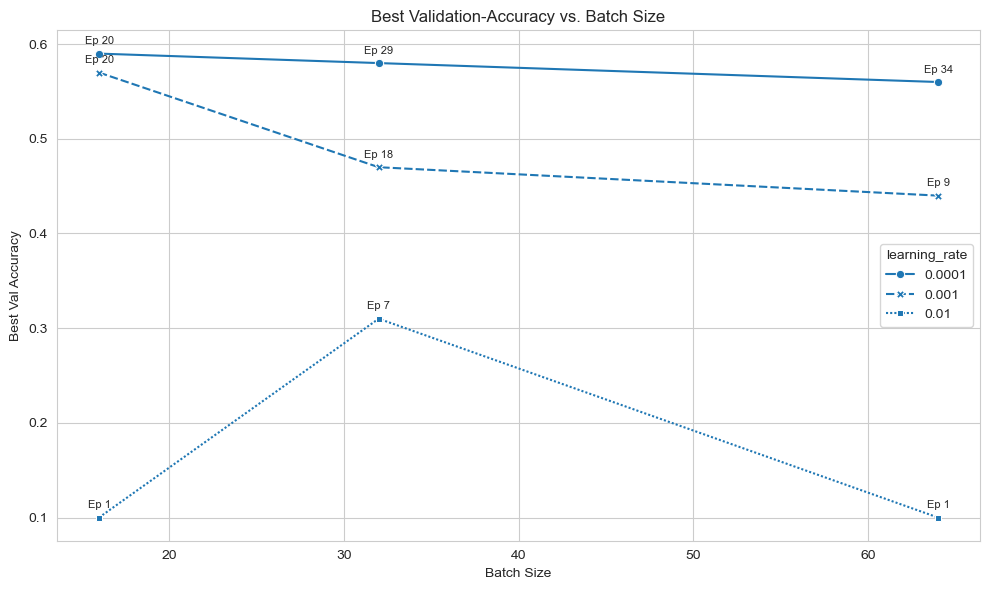

In [35]:
# Filter for best val-accuracy and according epoch
best_val_acc = (
    df.loc[df.groupby(['batch_size', 'learning_rate', 'optimizer'])['val_accuracy'].idxmax()]
    .reset_index(drop=True)
)

# Plot validation accuracy vs. batch size
plt.figure(figsize=(10, 6))
scatter = sns.lineplot(
    data=best_val_acc,
    x='batch_size',
    y='val_accuracy',
    style='learning_rate',
    palette='deep',
    sizes=(50, 200),
    legend='full', 
    markers=True,
)

# Show epoch numbers as txt labels
for _, row in best_val_acc.iterrows():
    plt.text(row['batch_size'], row['val_accuracy'] + 0.01, f"Ep {int(row['epoch'])}", 
             ha='center', fontsize=8)

# title etc. 
plt.title("Best Validation-Accuracy vs. Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Best Val Accuracy")
plt.grid(True)
plt.tight_layout()
if save_plot_files: 
    plt.savefig(f"{date.today().strftime('%y%m%d')}_HT_val-vs-batch_50sam_conv4_lin3_ep50.png", dpi=600, bbox_inches='tight')
if show_plot_files:
    plt.show()

**Interpretation of the plots:**

In this plot the best validation accuracy is plotted for each batch size and learning rate. Supplementary the epoch in which this val-accuracy could be performed is denoted.
Also in this plot it can be seen immediately that the learning rate of 0.01 has the lowest performance. Here it seem a bit more clear that the learning rate of 0.0001 is superior that the learning rate of 0.001 but only for batch sizes of 32 and 64. With a batch size of 16 the two learning rates perform relatively equal.

**Conclusion of the hyperparameter tuning:**

The Results should be handled with care since a relatively simple model architecture was used. If the architecture is changed or extended it can not be taken completely certain that the findings can also be applied to the new architecture. But it also seems that the architecture is too simple since the model overfits quite fast. This means the architecture should be extended and some regularizations should be applied. Last but not least these results are from a single assay. So no uncertainty was not determined.
As most suitable hyperparameters the following ones are considered for future trainings: 
- Learning Rate: 0.001 (This is a compromise between speed and performance, since the computational power is limited and the training time is very long. Smaller learning rates could be considered for running the training on the cluster.)
- Batch Size: 16 (This is the best performing batch size for the learning rate of 0.001)

### 5.3 Model Development
To develope the final model, which was presented in subsection 5.1 the single runs were performed with the evaluated hyperparameters and other settings (bs = 16, lr = 0.001, criterion = Adam, early stopping after 5 epochs without further decreases of the validation loss).

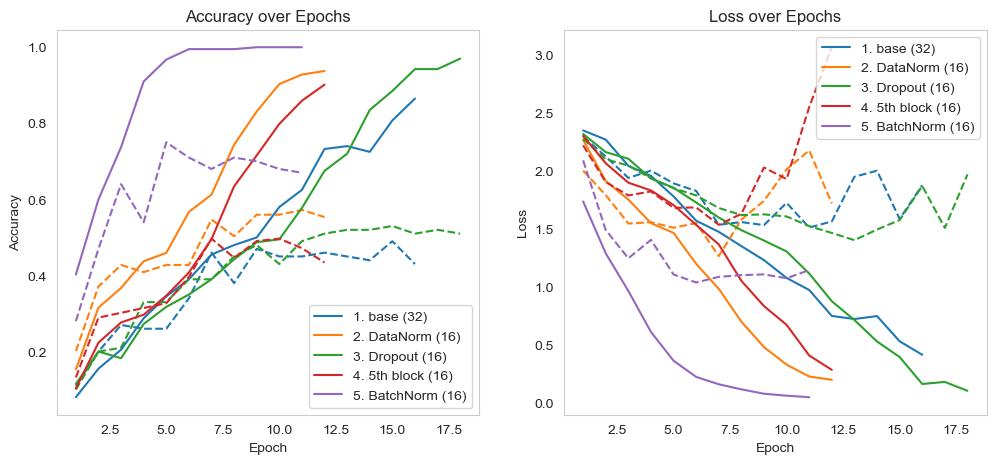

In [3]:
# Model comparison

# load data
df = pd.read_csv('./Model_dev_comparison.csv', delimiter = ';')
colors = sns.color_palette("tab10", n_colors=6)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Accuracy subplot ---
for i, (model_name, group) in enumerate(df.groupby("model")):
    axes[0].plot(group["epoch"], group["train_accuracy"], label=model_name, color = colors[i])
    axes[0].plot(group["epoch"], group["val_accuracy"], linestyle =  '--', label="_nolegend_", color = colors[i])
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(False)

# --- Loss subplot ---
for i, (model_name, group) in enumerate(df.groupby("model")):
    axes[1].plot(group["epoch"], group["train_loss"],  label=model_name, color = colors[i])
    axes[1].plot(group["epoch"], group["val_loss"], linestyle = '--' , label="_nolegend_", color = colors[i])
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(False)
if save_plot_files:
    filenname_model_dev =  os.path.join(script_directory, f"{date.today().strftime('%y%m%d')}_Model-dev.png")
    plt.savefig(filenname_model_dev, dpi=600)
    print(f"  - Model comparison Plot saved to file: {filenname_model_dev}")


*Validation is displayed as dashed lines*

| # | Name       | Batch Size | 5th layer | batchNorm | DataNorm | Dropout |
|---|------------|-------------|-----------|-----------|----------|---------|
| 1 | base       | 32          | ✗         | ✗         | ✗        | ✗       |
| 2 | DataNorm   | 16          | ✗         | ✗         | ✓        | ✗       |
| 3 | Dropout    | 16          | ✗         | ✗         | ✓        | ✓       | 
| 4 | 5th        | 16          | ✓         | ✗         | ✓        | ✓       |
| 5 | BatchNorm  | 16          | ✗         | ✓         | ✓        | ✓       |

The table shows the different conditions of the displayed training curves in the graphic above. So the different development steps always include the previous measure. 

**Interpretation of the Model Development**

As already mentioned not all development steps brought an improvement. In the graphic above the accuracy and the loss over the development steps are visualized. The dashed line shows the validation accuracy respectively the validation loss. 

Data Normalization as well as Batch Normalization could improve the model a lot. This can be seen that the over all accuracy is higher / the overall loss is lower for the BatchNorm in orange and the DataNorm in green. Also, the accuracy increases / loss decreases more rapidly compared to the other models. 

It seems that dropout also could improve the model slightly. Early stopping is activated if the validation loss has not been decreased for five epochs. After implementing dropout the validation loss did converge slower and more stable than in the basemodel. 

The implementation of a fifth convolutional block did not improve the models performance this is against the expectation. This can be seen at the rapid increase of the validation loss (blue dashed line). This might be a hint that the 5th layer leeds to overfitting maybe because the dataset is rather small or not diverse enough and therefore the model learns irrelevant details or noise.


### 5.4 Evaluation of Finetuning
In this section the finetuning is further considered. The finetuning was done on our pretrained model we developed (see 5.3 section above). 

We compare the finetuning of the whole model (feature extractor and classifier) with the finetuning of only the classifier (the last fully connected layer). The finetuning of only the classifier was done with 100% of the data but also with 50% of the data.

The training occured in all cases with a learning rate of 0.001, batch size of 16 and the Adam criterion. Early stopping got activated after 5 epochs without improvement of the val-loss.

**Training Process**

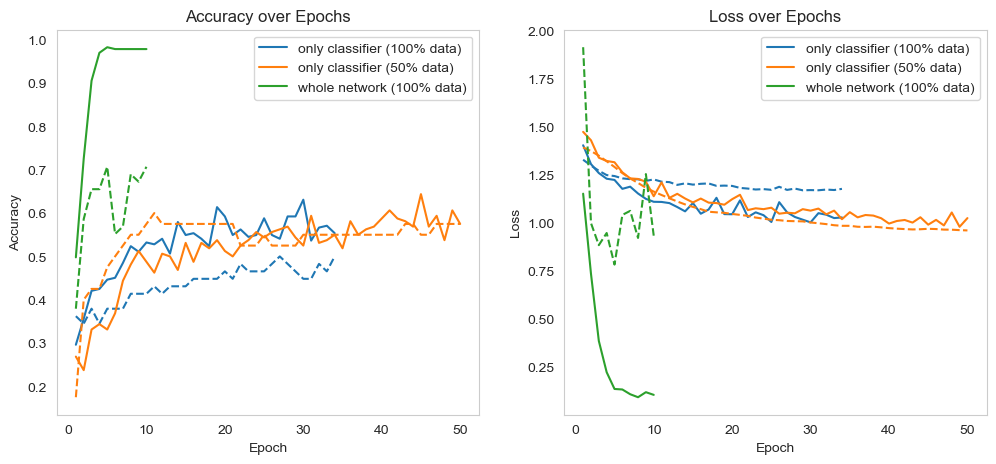

In [37]:
# Model comparison

# load data
df = pd.read_csv('./Model_finetune.csv', delimiter = ';')
colors = sns.color_palette("tab10", n_colors=3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Accuracy subplot ---
for i, (model_name, group) in enumerate(df.groupby("model")):
    axes[0].plot(group["epoch"], group["train_accuracy"], label=model_name, color = colors[i])
    axes[0].plot(group["epoch"], group["val_accuracy"], linestyle =  '--', label="_nolegend_", color = colors[i])
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(False)

# --- Loss subplot ---
for i, (model_name, group) in enumerate(df.groupby("model")):
    axes[1].plot(group["epoch"], group["train_loss"],  label=model_name, color = colors[i])
    axes[1].plot(group["epoch"], group["val_loss"], linestyle = '--' , label="_nolegend_", color = colors[i])
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(False)
if save_plot_files:
    filenname_model_dev =  os.path.join(script_directory, f"{date.today().strftime('%y%m%d')}_Model-dev.png")
    plt.savefig(filenname_model_dev, dpi=600)
    print(f"  - Model comparison Plot saved to file: {filenname_model_dev}")

*Validation is displayed as dashed lines*

**Interpretation: Training Process**

First of all it stands out that the chosen "parameters" strongly affect how fast early stopping is getting activated. If the whole network is trained with 100% of the data overfitting occurs quite fast and the val-loss increases again after a few epochs. Nevertheless the best accuracy could be achieved here, the val-accuracy is also higher than in the other finetunings but could still be improved. 

How much data is used seems to have less strong effect on the training process. It can be observed that with 100% of the data the model tends faster to overfit. Visible as the validation loss deviates earlier from the training loss. On the other hand this is not the case for the classifier training with reduced data where the trainig- and the validation loss do show a similar progress over the 50 epochs. 

**Model Performance**

The classifications reports and confusion matrices of the three finetuned models are presented below to elaborate their performance in general and across the genres. Firstly each report / matrix is interpreted on its own and then an overall interpretation is given. 

In [39]:
# Display Plots
HTML('<img src = "./Plots_Finetune_Model/250517_clf-cm_ft_classifier.png", width="1250"/>')




***only classifier with 100% of the data***

Lets have a look at the single classes first: the precision of proghouse is with 0.46 the lowest. This means that out of all cases that were predicted as proghouse only 46% were indeed proghouse. A similar picture can be found among the other genres. Trance shows the highest precision where 58% of the predicted samples were actually trance. Therefor the over all precision is 52% which is considered rather weak. 
 
Looking at the recall among the genres minihouse (0.67) and psytrance (0.72) more true cases are actual predicted as true, whereas among the classes proghouse (0.33) and trance (0.37) only a few of the true cases were predicted as true. This means the model does quite often missclassify proghouse and trance. For example the model predicts a lot of trance samples as minihouse and a lot of proghouse samples were predicted as psytrance. The over all recall is 0.52 which is also considered weak.

Considering the f1-score the model performs best for psytrance (0.60) and worst for proghouse (0.39). This lead to the conclusion that the model is not able to capture the characteristics of the different electronic genres well.

In [40]:
HTML('<img src = "./Plots_Finetune_Model/250520_clf-cm_ft_classifier_50samples.png", width="1250"/>')



***only classifier with 50% of the data***

With reduced data, the overall  precision as well as recall is slightly improved compared to the model trained with 100% of the data. At first this is contraintuitive as we would expect that with more data the model would be better learn the necessary features. When considering the training processes above, one can see that the model with 100% data tended more to overfitt, especially if we look at the validation accuracy (50% data) which is higher than the val-accuracy of the run with 100% data this can be confirmed. On the other hand it has to be said, that there are only a single run for each. This is statistically insufficient. Which means that this could just be variance.

Regarding the single classes, proghouse has still the worst precision (0.45) but the best precision is in this case psytrance (0.78). The recall shows a similar pictures as in the clf above. It is hard for the model to find all the true samples of proghouse (0.5) and especially trance (0.3). Psytrance and Minihouse on the other hand 70% respectively 80% of the true positive samples are predicted correctly.



In [41]:
HTML('<img src = "./Plots_Finetune_Model/250518_clf-cm_ft_wholenet.png", width="1250"/>')


***whole pretrained network with 100% of the data***

Finally, the model in which not only the classifier but also the feature extractor was trained on 100% of the data. Here the lowest precision belongs to the genre psytrance (0.53) which has at the same time the highest recall. This means that the model wrongly classifies many other samples as psytrance (in this case trance) but only misclasifies a low amount of psytrance samples wrong (to other classes).  The opposite is true for minihouse. There are no false positive cases, so no samples of the other classes are wrongly calssified as minihouse which results in a precision of 1. Unfortunately half of the minihouse samples were classified wrong which resulted in a recall of 0.5.
Proghouse and trane have similar precision and recall values. 

The overall precision is 0.71 and the overall recall is 0.64. Therefore, this model performed better than the two previous. This makes sense since the model has the opportunity to learn or adjust its weights to the features of the new data whereas in the other two cases only the final classifier is finetuned.



**Interpretation of the performance of the finetuned models**

It could be shown that the best performance was achieved with the full dataset and finetuning the whole model. On the other hand training only the classifier shows not the same performance but using only the half dataset does not necessarily result in worse performance. Nonetheless the results have to be handled with care since these are only single assays. 


### 5.5 Model Comparison
Here the model performance of our finetuned model and of the finetuned MobileNet_v2 and ResNet18 are compared. The Models were all finetuned on our own data but only 50 samples were used such that the training could be finished without crashing (which was the case using the full dataset on the foreing models). Early stopping could not be reached so that all three models were trained for 50 epochs and then stopped. 

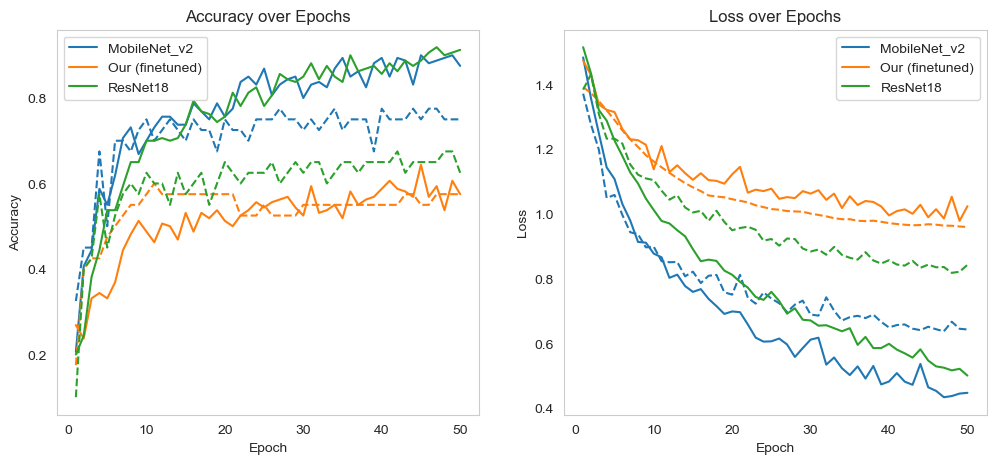

In [42]:
# load data
df = pd.read_csv('./Model_final_comparison.csv', delimiter = ';')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Accuracy subplot ---
for i, (model_name, group) in enumerate(df.groupby("model")):
    axes[0].plot(group["epoch"], group["train_accuracy"], label=model_name, color = colors[i])
    axes[0].plot(group["epoch"], group["val_accuracy"], label="_nolegend_", color = colors[i], linestyle = '--')
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(False)

# --- Loss subplot ---
for i, (model_name, group) in enumerate(df.groupby("model")):
    axes[1].plot(group["epoch"], group["train_loss"], label=model_name, color = colors[i])
    axes[1].plot(group["epoch"], group["val_loss"], label="_nolegend_", color = colors[i], linestyle = '--')
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(False)
if save_plot_files:
    filenname_model_comp =  os.path.join(script_directory, f"{date.today().strftime('%y%m%d')}_Model-Comp.png")
    plt.savefig(filenname_model_comp, dpi=600)
    print(f"  - Model comparison Plot saved to file: {filenname_model_comp}")


**Interpretation of the Comparison**

The above plot shows the accuracy and loss for the training (full line) and validation (dashed line) over the ran epochs. Looking at the train-loss it seems that the foreing models are quite similar but the validation-loss indicates that ResNet18 overfits earlier than MobileNet_v2. Our own model shows less overfitting concerning the deviation of training and validation loss but still can't reach the same accuracy/loss as the foreing models.  

Below the clf and cm of the foreing models are shown (our own was already showed above in subsection 5.4) which allows a deeper view in to the actuall performance. 

In [43]:
HTML('<img src = "./Plots_Finetune_Model/250520_clf-cm_ResNet18.png", width="1250"/>')


***ResNet18***

As well as our own finetuned model Resnet18 shows lower precision and recall for the genres proghouse and trance. Especially the recall for proghouse (0.2) is extremely low. The model classified 7 out of 10 proghouse samples as trance. Minihouse and psytrance on the other hand do have high precision and recall. This leads to an overall precision of 0.62 which is considered medioker. 

In [44]:
HTML('<img src = "./Plots_Finetune_Model/250520_clf-cm_MobileNet_v2.png", width="1250"/>')

***MobileNet_v2***

The finetuned MobileNet_v2 shows the highest peformance of all finetuned networks. The average precision is 0.77 and  average recall 0.75. The weakest genre in terms of precision is in this case minihouse with 0.69. Directly after that is proghouse and trance with a precision of 0.7 whereas for psytrance were no false positive resulting in a precision of 1. The best recall can be found for minihouse (0.9).  

**Conclusion of the model comparison:**

The finetuned MobileNet_v2 outperforms our own model and ResNet18. Even our finetuned model (feature extractor and classifier) with 100% of the data could not perform equaly well as the finetuned MobileNet_v2. The performance of ResNet18 is surprisingly weak. MobileNet_v2 does not only convince with the over all performance but also has no class with a distinctive weakness.

## 6. Final Remarks

### 6.1 Overall Conclusion
**Data**

The used dataset seemed to be rather small but already challegend our local machines. It might be an advantage to use more data as well as more genres to improve the model performance and increase its generalizability. Also, the data was nicely balanced which bared us from further measures to handle imbalances. 

**Base model and development process**

Starting with simple architecture over some iterative steps usefull addition could be made to improve the model performance. Especially Data Normalization and Batch Normalization had a large impact on accuracy as well as loss. Dropout applied to the first two fully connected layers also reduced overfitting. Implementing more blocks or different block architechture could not improve the model in our case.


**Hyperparameter tuning**

A hyperparameter tuning was successfully performed to find the best learning rate, the batch size and the optimizer out of a basic selection. The chosen hyperparameters were a compromise between performance and efficiency since the training was performed on a local machine. In our case this was: 
* Learning Rate = 0.001
* Batch Size = 16
* Optimizer = Adam

**Finetuning/transferlearing**

As established in section 5.4 Evaluation of Finetunig better results were achieved training the whole net (feature extractor and classifier) than only the classifier.



### 6.2 Problems Encountered

**Data**

The data (mel-spectrograms) from Kaggle could not be reproduced. Therefor the mel-spectrograms had to be recreated for all .wav samples. It couldn't be managed to create smaller images that with size of 400 x 1000 pixels. These larger image sizes required quite high amount of computational power. Which limited then the size of our dataset for the training.  

All trainings that were performed with reduced datasets did not contain a test set. This was detected after some trainings had been done already. To ensure comparability we proceeded like this. Of course this is not optimal and the predictions of the models were done with the already used validation sets. This issue occured because the initial intension of the subset was only to use it for code and model development and not for the final evaluation. For the future it would be good to also implement a test set in the subset.  

**Training on Earth Cluster** 

We started quite early with the project and arranged to use the earth cluster. Although we encounterd many problems to run our scripts there and produce meaning full results. To name some of them, setting up the environment and the bashfiles as well as not learning models after 100 epochs. Resolving this problems couldn't be managed in a reasonable amount of time. To proceed the approach of training a small model on a local computer was chosen. 


**Model Architecture and Training**

It was tried to implement code for dynamic model building. This did not work because the training had no effect and the models didn't learn. Retrospective this was maybe tried for too long until the step back to classic model building. 
 Experimenting with the model architecture required model training. Often the training took quite long and led to a fatal system crash. This limited the experimenting. 


### 6.3 Outlook
To further enhance model performance and robustness, several improvements can be considered:

Data Augmentation: Applying data augmentation techniques can increase the diversity of the training set and help prevent overfitting.

Scalability: Utilizing larger models on the earth cluster would allow for more complex architectures that could potentially yield better results.

Optimization Strategies: Exploring alternative optimizers beyond SGD and Adam, such as RMSprop, AdaBelief, or newer adaptive methods, may lead to better convergence properties.

Statistical Reliability: Ensuring a statistically sufficient number of experimental runs would improve the reliability and generalizability of performance metrics.

Genre-specific Evaluation: Classification accuracy should also be reported separately for each genre by setting average=None in the evaluation metric. This would offer deeper insights into genre-specific model behavior.

Hyperparameter Tuning:

Batch Size: A broader range (e.g., 2 to 128) should be explored to identify optimal batch sizes across different model configurations.

Learning Rate: A finer granularity for learning rate selection (e.g., 0.0001 to 0.005) may uncover more optimal training dynamics.

Dropout Rate: Tuning the dropout rate (e.g., from 0.1 to 0.5) could help control overfitting while maintaining model capacity.

These enhancements would contribute to a more thorough and accurate evaluation of model performance while potentially improving overall predictive capabilities.